In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import seaborn as sns

# Import the core functions from our library
#from tsne_jax import *
from utils import *

cm = 1/2.54  # centimeters in inches

import os
tex_path = '/ceph/ibmi/it/users/zabel/texlive/2025/bin/x86_64-linux' # <-- IMPORTANT: Change this to your actual path
os.environ['PATH'] = tex_path + os.pathsep + os.environ['PATH']

plt.rcParams.update({
    "text.usetex": True,
})

/tmp/ipykernel_2534908/194996692.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[0, 0].scatter(Y_star[inds, 0], Y_star[inds, 1], c = color_mapping[i], label=f'$t_{idx+1}$', marker='o')
/tmp/ipykernel_2534908/194996692.py:79: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[1, 1].scatter(s[0], s[1], c=palettes.tue_plot[i], alpha=[i for i in np.arange(0.1, 1, 1/(n_samples+2))][j], marker='.')
/tmp/ipykernel_2534908/1

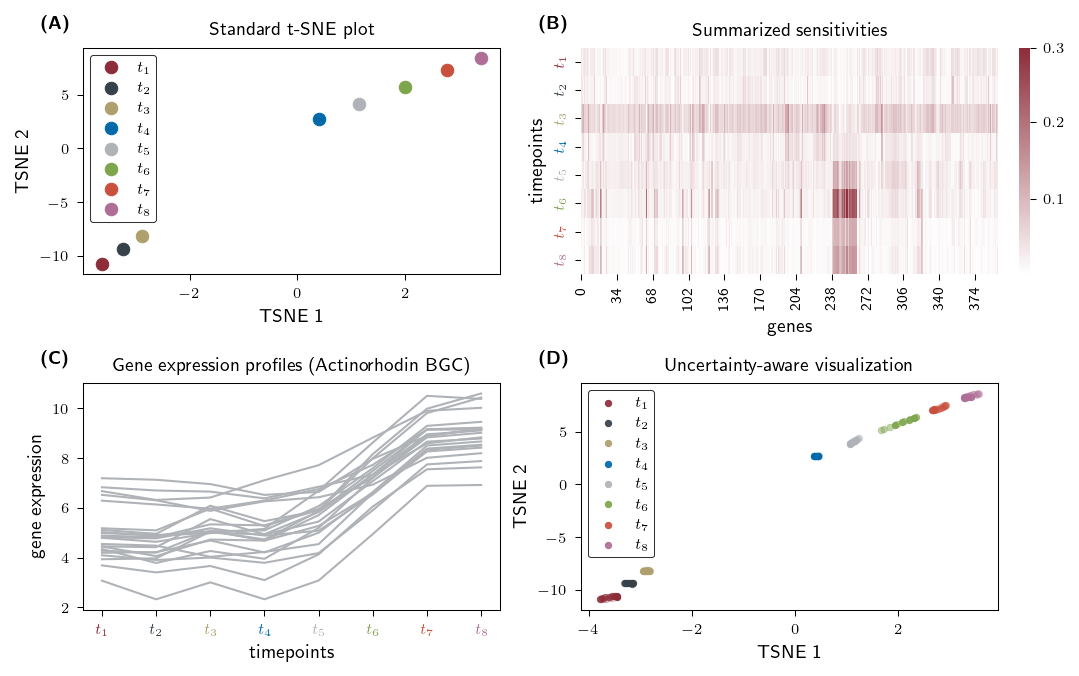

In [ ]:
from tueplots import axes, bundles
from tueplots.constants.color import palettes
from matplotlib.transforms import ScaledTranslation



labels_unique = ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']
labels = labels_unique
Y_star = np.load('..data/M145/tsne_embedding.npy')

cmap = palettes.tue_plot
color_mapping = {label: cmap[i] for i, label in enumerate(labels_unique)}

sensitivities_summarized = np.load('..data/M145/sensitivities_summarized.npy')
cmap_heatmap = mpl.colors.LinearSegmentedColormap.from_list("", [palettes.tue_plot[3], "white", palettes.tue_plot[0]])

X = np.load('..data/M145/actinorhodin.npy')

samples = np.load('..data/M145/samples_for_animation.npy')
n_samples = 15

with plt.rc_context({**bundles.aistats2022(family="serif"), **axes.lines()}):
  mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
  #fig, axs = plt.subplot_mosaic([['a)', 'b)'], ['c)', 'd)']], figsize=(180*cm, 0.75*180*cm), )
  fig, axs = plt.subplots(2, 2, figsize=(18.0*cm, 0.62*18.0*cm), )
  #plt.hist(np.clip(var_a_nn, a_min=0, a_max=10), 50)
  for idx, i in enumerate(labels_unique):
    inds = [j == i for j in labels]
    axs[0, 0].scatter(Y_star[inds, 0], Y_star[inds, 1], c = color_mapping[i], label=f'$t_{idx+1}$', marker='o')
  axs[0, 0].set_xlabel('TSNE 1')
  axs[0, 0].set_ylabel('TSNE 2')
  axs[0, 0].set_title('Standard t-SNE plot')
  axs[0, 0].legend()
  axs[0, 0].text(
        0.0, 1.0, r'\textbf{(A)}', transform=(
            axs[0, 0].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)), va='bottom')
  
  sns.heatmap(sensitivities_summarized, cmap=cmap_heatmap, norm=(MidpointNormalize(midpoint=0, vmin=np.min(sensitivities_summarized), vmax=np.max(sensitivities_summarized))), ax=axs[0, 1])
  x_ticks = [0.5, 34.5, 68.5, 102.5, 136.5, 170.5, 204.5, 238.5, 272.5, 306.5, 340.5, 374.5]
  x_tick_labels = [0, 34, 68, 102, 136, 170, 204, 238, 272, 306, 340, 374]
  axs[0, 1].set_xticks(x_ticks)
  axs[0, 1].set_xticklabels(x_tick_labels, rotation=90)

  # Y-axis ticks and labels
  y_ticks = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]
  # Matplotlib's mathtext can render LaTeX-style strings like $t_1$
  y_tick_labels = [f'$t_{i}$' for i in range(1, 9)]
  axs[0, 1].set_yticks(y_ticks)
  axs[0, 1].set_yticklabels(y_tick_labels)
  axs[0, 1].set_xlabel('genes')
  axs[0, 1].set_ylabel('timepoints')
  axs[0, 1].set_title('Summarized sensitivities')
  # Set the color for each individual y-tick label
  for label, color in zip(axs[0, 1].get_yticklabels(), cmap[0:8]):
      label.set_color(color)
  axs[0, 1].text(
        0.0, 1.0, r'\textbf{(B)}', transform=(
            axs[0, 1].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)), va='bottom')
  
  axs[1, 0].plot(X, c=palettes.tue_plot[4])
  axs[1, 0].set_xticks(ticks=[0, 1, 2, 3, 4, 5, 6, 7], labels=[f'$t_{i}$' for i in range(1, 9)])
  axs[1, 0].set_xlabel('timepoints')
  axs[1, 0].set_ylabel('gene expression')
  axs[1, 0].set_title('Gene expression profiles (Actinorhodin BGC)')
  for label, color in zip(axs[1, 0].get_xticklabels(), cmap[0:8]):
      label.set_color(color)
  axs[1, 0].text(
      0.0, 1.0, r'\textbf{(C)}', transform=(
          axs[1, 0].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)), va='bottom')
  # plt.savefig('paper_figures/figure_03.pdf', dpi=150)


  for j, sample in enumerate(samples.T):
      sample = sample.reshape((8, 2))
      for i, s in enumerate(sample):
          if j==n_samples-1:
            axs[1, 1].scatter(s[0], s[1], c=palettes.tue_plot[i], alpha=[i for i in np.arange(0.1, 1, 1/(n_samples+2))][j], marker='.', label=f'$t_{i+1}$')
          else:
             axs[1, 1].scatter(s[0], s[1], c=palettes.tue_plot[i], alpha=[i for i in np.arange(0.1, 1, 1/(n_samples+2))][j], marker='.')
  axs[1, 1].set_xlabel('TSNE 1')
  axs[1, 1].set_ylabel('TSNE 2')
  axs[1, 1].set_title('Uncertainty-aware visualization')
  axs[1, 1].legend()

  axs[1, 1].text(
      0.0, 1.0, r'\textbf{(D)}', transform=(
          axs[1, 1].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)), va='bottom')
  plt.savefig('figures_and_animations/M145.pdf', dpi=150)


# Individual plots

In [ ]:
with plt.rc_context({**bundles.aistats2022(family="serif"), **axes.lines()}):
  mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
  #fig, axs = plt.subplot_mosaic([['a)', 'b)'], ['c)', 'd)']], figsize=(180*cm, 0.75*180*cm), )
  fig, axs = plt.subplots(1, 1, figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))
  #plt.hist(np.clip(var_a_nn, a_min=0, a_max=10), 50)
  for idx, i in enumerate(labels_unique):
    inds = [j == i for j in labels]
    axs.scatter(Y_star[inds, 0], Y_star[inds, 1], c = color_mapping[i], label=f'$t_{idx+1}$', marker='o')
  axs.set_xlabel('TSNE 1')
  axs.set_ylabel('TSNE 2')
  axs.set_title('Standard t-SNE plot')
  axs.legend()
  plt.savefig('figures_and_animations/M145_1.pdf', dpi=150)


/tmp/ipykernel_2534908/1191679363.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(Y_star[inds, 0], Y_star[inds, 1], c = color_mapping[i], label=f'$t_{idx+1}$', marker='o')


In [ ]:
with plt.rc_context({**bundles.aistats2022(family="serif"), **axes.lines()}):
  mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
  #fig, axs = plt.subplot_mosaic([['a)', 'b)'], ['c)', 'd)']], figsize=(180*cm, 0.75*180*cm), )
  fig, axs = plt.subplots(1, 1, figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))
  sns.heatmap(sensitivities_summarized, cmap=cmap_heatmap, norm=(MidpointNormalize(midpoint=0, vmin=np.min(sensitivities_summarized), vmax=np.max(sensitivities_summarized))), ax=axs)
  x_ticks = [0.5, 34.5, 68.5, 102.5, 136.5, 170.5, 204.5, 238.5, 272.5, 306.5, 340.5, 374.5]
  x_tick_labels = [0, 34, 68, 102, 136, 170, 204, 238, 272, 306, 340, 374]
  axs.set_xticks(x_ticks)
  axs.set_xticklabels(x_tick_labels, rotation=90)

  # Y-axis ticks and labels
  y_ticks = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]
  # Matplotlib's mathtext can render LaTeX-style strings like $t_1$
  y_tick_labels = [f'$t_{i}$' for i in range(1, 9)]
  axs.set_yticks(y_ticks)
  axs.set_yticklabels(y_tick_labels)
  axs.set_xlabel('genes')
  axs.set_ylabel('timepoints')
  axs.set_title('Summarized sensitivities')
  # Set the color for each individual y-tick label
  for label, color in zip(axs.get_yticklabels(), cmap[0:8]):
      label.set_color(color)

  plt.savefig('figures_and_animations/M145_2.pdf', dpi=150)

In [ ]:
with plt.rc_context({**bundles.aistats2022(family="serif"), **axes.lines()}):
  mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
  #fig, axs = plt.subplot_mosaic([['a)', 'b)'], ['c)', 'd)']], figsize=(180*cm, 0.75*180*cm), )
  fig, axs = plt.subplots(1, 1, figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))

  axs.plot(X, c=palettes.tue_plot[4])
  axs.set_xticks(ticks=[0, 1, 2, 3, 4, 5, 6, 7], labels=[f'$t_{i}$' for i in range(1, 9)])
  axs.set_xlabel('timepoints')
  axs.set_ylabel('gene expression')
  axs.set_title('Gene expression profiles (Actinorhodin BGC)')
  for label, color in zip(axs.get_xticklabels(), cmap[0:8]):
      label.set_color(color)
  plt.savefig('figures_and_animations/M145_3.pdf', dpi=150)

In [ ]:
with plt.rc_context({**bundles.aistats2022(family="serif"), **axes.lines()}):
  mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
  #fig, axs = plt.subplot_mosaic([['a)', 'b)'], ['c)', 'd)']], figsize=(180*cm, 0.75*180*cm), )
  fig, axs = plt.subplots(1, 1, figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))
  for j, sample in enumerate(samples.T):
      sample = sample.reshape((8, 2))
      for i, s in enumerate(sample):
          if j==n_samples-1:
            axs.scatter(s[0], s[1], c=palettes.tue_plot[i], alpha=[i for i in np.arange(0.1, 1, 1/(n_samples+2))][j], marker='.', label=f'$t_{i+1}$')
          else:
             axs.scatter(s[0], s[1], c=palettes.tue_plot[i], alpha=[i for i in np.arange(0.1, 1, 1/(n_samples+2))][j], marker='.')
  axs.set_xlabel('TSNE 1')
  axs.set_ylabel('TSNE 2')
  axs.set_title('Uncertainty-aware visualization')
  axs.legend()
  plt.savefig('figures_and_animations/M145_4.pdf', dpi=150)

/tmp/ipykernel_2534908/420481147.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(s[0], s[1], c=palettes.tue_plot[i], alpha=[i for i in np.arange(0.1, 1, 1/(n_samples+2))][j], marker='.')
/tmp/ipykernel_2534908/420481147.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(s[0], s[1], c=palettes.tue_plot[i], alpha=[i for i in np.arange(0.1, 1, 1/(n_samples+2))][j], marker='.', label=f'$t_{i+1}$')


In [ ]:
from tueplots import cycler, fonts, fontsizes, bundles
from tueplots.constants import markers
from tueplots.constants.color import palettes
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter


def animate(samples, labels, output, cmap):
    plt.rcParams.update(cycler.cycler(color=palettes.tue_plot))
    #plt.rcParams.update(fonts.aistats2022_tex(family="serif"))
    #plt.rcParams.update(fontsizes.aistats2022())
    plt.rcParams['axes.grid'] = False

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    cs = le.fit_transform(labels)
    print(cs)
    cs = [palettes.tue_plot[i] for i in cs]
    print(cs)
    labels_set = list(dict.fromkeys(labels))
    print(labels_set)

    fig, ax = plt.subplots(figsize=(7, 5))
    sample_0 = samples[:, 0]
    sample_0 = sample_0.reshape((len(labels), 2))
    minimum_x = np.min(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 0])
    maximum_x = np.max(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 0])
    minimum_y = np.min(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 1])
    maximum_y = np.max(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 1])
    ax.set_xlim((minimum_x - (0.1 * (maximum_x - minimum_x)), maximum_x + (0.1 * (maximum_x - minimum_x))))
    ax.set_ylim((minimum_y - (0.1 * (maximum_y - minimum_y)), maximum_y + (0.1 * (maximum_y - minimum_y))))
    ax.set_xlabel('TSNE 1')
    ax.set_ylabel('TSNE 2')
    scat = ax.scatter(sample_0[:, 0], sample_0[:, 1], c=cs)
    # Manually create a legend
    legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cs[i], markersize=8, label=label)
                  for i, label in enumerate(labels_set)]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.04, 1), loc="upper left")    
    plt.tight_layout()

    def init():
        return scat,

    def animate(i):
        sample_i = samples[:, i]
        sample_i = sample_i.reshape((len(labels), 2))
        scat.set_offsets(sample_i)
        return scat, 
        
    anim = FuncAnimation(
        fig, animate, interval=1000, frames=samples.shape[1], blit=True, init_func=init)
        
 
    #anim.save("ifd_results/ifd.mov", dpi=150, writer=FFMpegWriter(fps=5))
    #anim.save("laplace_approximation/laplace.mov", dpi=150, writer=FFMpegWriter(fps=5))
    #anim.save("laplace_approximation/laplace.gif", dpi=150, writer=PillowWriter(fps=1000))
    anim.save(output, dpi=150, writer=PillowWriter(fps=5))
    # Currently used
    # first option
    #anim = FuncAnimation(
    #    fig, animate, interval=1000, frames=40, blit=True, init_func=init)
    #anim.save(output, dpi=150, writer=FFMpegWriter(fps=2))

    # second option
    # anim = FuncAnimation(
    #     fig, animate, interval=200, frames=40, blit=True, init_func=init)
    # with open(output, "w") as f:
    #     print(anim.to_html5_video(), file=f)
animate(samples, labels, 'figures_and_animations/M145.gif', cmap=palettes.tue_plot)